Two-stage convex solver
Stage 1: joint A,B,C,L
Stage 2: freeze A,B,C and refit only L
n1=120, n2=140, d1=5, d2=6, r_true=3
p_obs=0.3, sigma=0.001

Stage 1 settings:
lambda_stage1=5.000000e-01
eta_A=6.120307e+00, eta_B=6.799254e-02, eta_C=6.751078e-02, eta_L=6.000000e-02

Truth feasibility check:
||Z^T B||_F = 5.658122328083774e-15
||W^T C||_F = 5.773170153062291e-15
||W^T L||_F = 8.609362063703791e-16
||L Z||_F   = 9.406347501091904e-16

True component Frobenius norms:
{'WAZ': 12.577621477595056, 'WBt': 29.57046994116156, 'CZT': 32.53033543771627, 'L': 8.077747210701755}

[Stage 1] Iter    1 | obj = 2.443994e+02 | err_D = 4.6446e-01 | err_A = 4.7742e-01 | err_B = 4.6805e-01 | err_C = 4.6743e-01 | err_L = 4.1598e-01 | rank(L) = 102 | rel_change = 2.095e-01
[Stage 1] Iter   10 | obj = 8.712149e+01 | err_D = 3.2731e-01 | err_A = 3.6891e-01 | err_B = 3.2595e-01 | err_C = 3.2409e-01 | err_L = 5.3270e-01 | rank(L) = 56 | rel_change = 2.920e-02
[Stage 1] Iter   20 | obj = 5.486096e+01 | err_D

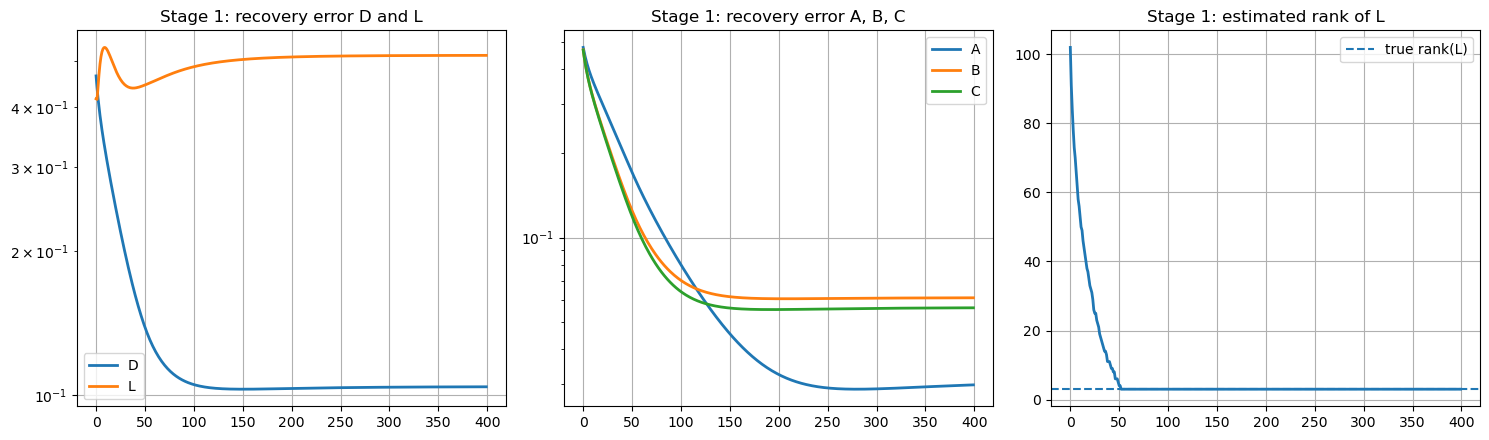

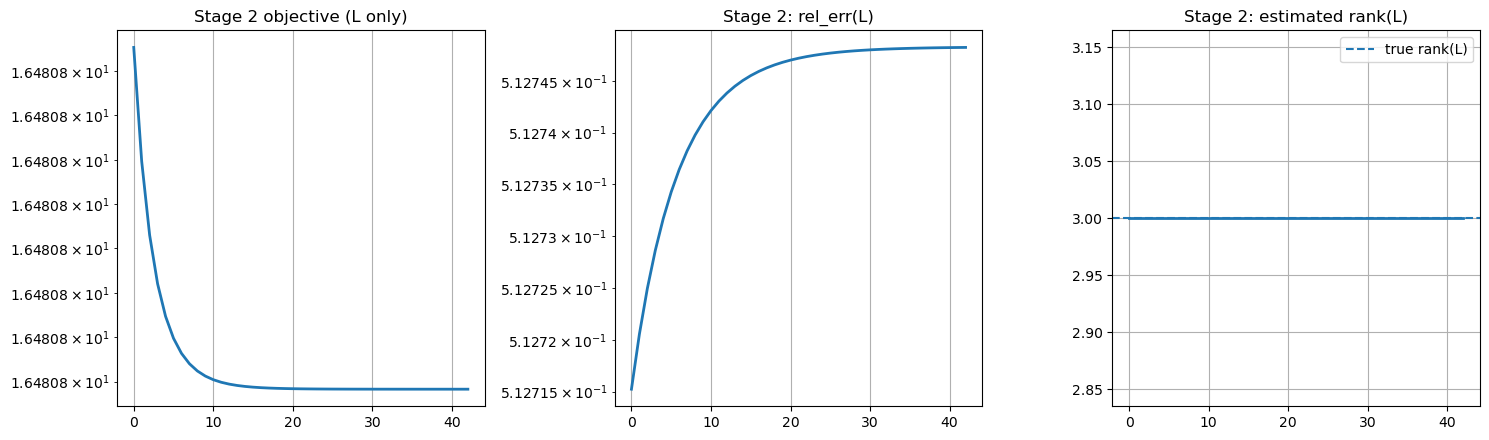

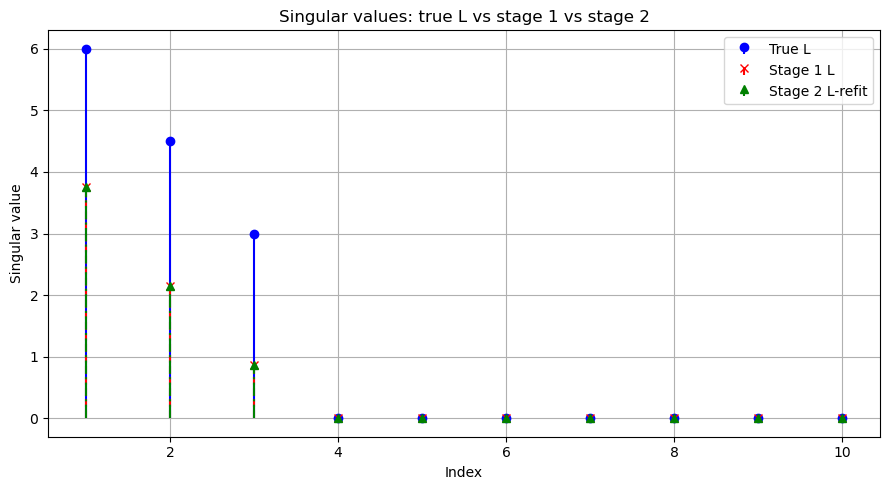

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Two-stage convex solver for the full model
#
#   M* = W A Z^T + W B^T + C Z^T + L
#
# Objective in stage 1:
#   min_{A,B,C,L in R(W,Z)}
#       (1/(2p)) * || P_Omega(WAZ^T + WB^T + CZ^T + L - M_obs) ||_F^2
#       + (lambda/p) * ||L||_*
#
# Stage 2:
#   Freeze A,B,C at their learned stage-1 values, and refit only L:
#
#   min_{L in S}
#       (1/(2p)) * || P_Omega(L - R_ABC_obs) ||_F^2
#       + (lambda_refit/p) * ||L||_*
#
# where
#   R_ABC_obs = M_obs - P_Omega(W A_hat Z^T + W B_hat^T + C_hat Z^T),
# and S = {L : W^T L = 0, L Z = 0}.
# ============================================================


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def fro_norm(X):
    return np.linalg.norm(X, ord="fro")


def relative_fro_error(X_hat, X_true, eps=1e-12):
    return fro_norm(X_hat - X_true) / (fro_norm(X_true) + eps)


def projector_onto_colspace(X):
    """
    P_X = X (X^T X)^dagger X^T
    """
    return X @ np.linalg.pinv(X.T @ X) @ X.T


def projector_onto_orthogonal_complement(X):
    """
    P_X_perp = I - P_X
    """
    n = X.shape[0]
    return np.eye(n) - projector_onto_colspace(X)


def project_B_to_feasible(B, PZ_perp):
    return PZ_perp @ B


def project_C_to_feasible(C, PW_perp):
    return PW_perp @ C


def project_L_to_feasible(L, PW_perp, PZ_perp):
    return PW_perp @ L @ PZ_perp


def singular_value_thresholding(Y, tau):
    U, S, Vh = np.linalg.svd(Y, full_matrices=False)
    S_thresh = np.maximum(S - tau, 0.0)
    return U @ np.diag(S_thresh) @ Vh


def numerical_rank(X, rel_thresh=1e-3):
    s = np.linalg.svd(X, compute_uv=False)
    if s.size == 0 or s[0] <= 1e-15:
        return 0
    return int(np.sum(s > rel_thresh * s[0]))


# ------------------------------------------------------------
# Model pieces
# ------------------------------------------------------------
def component_interaction(W, Z, A):
    return W @ A @ Z.T


def component_B(W, B):
    return W @ B.T


def component_C(C, Z):
    return C @ Z.T


def compose_matrix(W, Z, A, B, C, L):
    return component_interaction(W, Z, A) + component_B(W, B) + component_C(C, Z) + L


def component_norms(W, Z, A, B, C, L):
    return {
        "WAZ": fro_norm(component_interaction(W, Z, A)),
        "WBt": fro_norm(component_B(W, B)),
        "CZT": fro_norm(component_C(C, Z)),
        "L": fro_norm(L),
    }


# ------------------------------------------------------------
# Initialization
# ------------------------------------------------------------
def scaled_relative_perturbation(base, noise, rel_level=0.5, eps=1e-12):
    base_norm = fro_norm(base)
    noise_norm = fro_norm(noise)

    if noise_norm < eps:
        return base.copy()

    if base_norm < eps:
        return noise.copy()

    alpha = rel_level * base_norm / (noise_norm + eps)
    return base + alpha * noise


def initialize_parameters(init_mode, A_true, B_true, C_true, L_true, W, Z, rng):
    """
    Supported modes:
        - "near_truth"
        - "random_feasible"
    """
    PW_perp = projector_onto_orthogonal_complement(W)
    PZ_perp = projector_onto_orthogonal_complement(Z)

    if init_mode == "near_truth":
        rel_level = 0.5

        E_A = rng.standard_normal(size=A_true.shape)
        A0 = scaled_relative_perturbation(A_true, E_A, rel_level=rel_level)

        E_B = rng.standard_normal(size=B_true.shape)
        E_B_feas = project_B_to_feasible(E_B, PZ_perp)
        B0 = scaled_relative_perturbation(B_true, E_B_feas, rel_level=rel_level)
        B0 = project_B_to_feasible(B0, PZ_perp)

        E_C = rng.standard_normal(size=C_true.shape)
        E_C_feas = project_C_to_feasible(E_C, PW_perp)
        C0 = scaled_relative_perturbation(C_true, E_C_feas, rel_level=rel_level)
        C0 = project_C_to_feasible(C0, PW_perp)

        E_L = rng.standard_normal(size=L_true.shape)
        E_L_feas = project_L_to_feasible(E_L, PW_perp, PZ_perp)
        L0 = scaled_relative_perturbation(L_true, E_L_feas, rel_level=rel_level)
        L0 = project_L_to_feasible(L0, PW_perp, PZ_perp)

    elif init_mode == "random_feasible":
        A0 = rng.standard_normal(size=A_true.shape)
        B0 = project_B_to_feasible(rng.standard_normal(size=B_true.shape), PZ_perp)
        C0 = project_C_to_feasible(rng.standard_normal(size=C_true.shape), PW_perp)
        L0 = project_L_to_feasible(rng.standard_normal(size=L_true.shape), PW_perp, PZ_perp)
    else:
        raise ValueError("init_mode must be 'near_truth' or 'random_feasible'")

    return A0, B0, C0, L0


# ------------------------------------------------------------
# Automatic step sizes
# ------------------------------------------------------------
def compute_step_sizes(W, Z, p_obs, cA=0.3, cB=0.3, cC=0.3, cL=0.2):
    """
    Conservative blockwise step sizes for stage 1.
    """
    n1 = W.shape[0]

    op_W = np.linalg.norm(W.T @ W, 2)
    op_Z = np.linalg.norm(Z.T @ Z, 2)

    L_A = (op_W * op_Z) / (n1 * p_obs)
    L_B = op_W / p_obs
    L_C = op_Z / p_obs
    L_L = 1.0 / p_obs

    eta_A = cA / (L_A + 1e-12)
    eta_B = cB / (L_B + 1e-12)
    eta_C = cC / (L_C + 1e-12)
    eta_L = cL / (L_L + 1e-12)

    return eta_A, eta_B, eta_C, eta_L


def compute_L_only_step_size(p_obs, cL=0.5):
    """
    For the L-only residual refit:
        smooth part = (1/(2p)) || P_Omega(L - R_obs) ||_F^2
    gradient Lipschitz constant is 1/p.
    """
    return cL * p_obs


# ------------------------------------------------------------
# Simulation
# ------------------------------------------------------------
def generate_feasible_truth(
    n1, n2, d1, d2, r_true, rng,
    scale_A=1.0, scale_B=1.0, scale_C=1.0, scale_L=1.0
):
    """
    Generate W, Z and true parameters satisfying:
        Z^T B = 0
        W^T C = 0
        W^T L = 0
        L Z   = 0
    """
    W = rng.standard_normal((n1, d1))
    Z = rng.standard_normal((n2, d2))

    W = W / np.sqrt(n1)
    Z = Z / np.sqrt(n2)

    PW_perp = projector_onto_orthogonal_complement(W)
    PZ_perp = projector_onto_orthogonal_complement(Z)

    A_true = scale_A * rng.standard_normal((d1, d2))

    B_raw = rng.standard_normal((n2, d1))
    B_true = scale_B * project_B_to_feasible(B_raw, PZ_perp)

    C_raw = rng.standard_normal((n1, d2))
    C_true = scale_C * project_C_to_feasible(C_raw, PW_perp)

    U0 = rng.standard_normal((n1, r_true))
    V0 = rng.standard_normal((n2, r_true))
    U_feas = PW_perp @ U0
    V_feas = PZ_perp @ V0

    U_true, _ = np.linalg.qr(U_feas)
    V_true, _ = np.linalg.qr(V_feas)

    sing_vals = np.linspace(2.0, 1.0, r_true)
    Sigma = np.diag(scale_L * sing_vals)
    L_true = U_true[:, :r_true] @ Sigma @ V_true[:, :r_true].T
    L_true = project_L_to_feasible(L_true, PW_perp, PZ_perp)

    return W, Z, A_true, B_true, C_true, L_true


def generate_observed_data(M_true, p_obs, sigma, rng):
    noise = rng.normal(0.0, sigma, size=M_true.shape)
    M_noisy = M_true + noise
    mask = (rng.random(M_true.shape) < p_obs).astype(float)
    M_obs = mask * M_noisy
    return M_obs, mask


# ------------------------------------------------------------
# Objectives and diagnostics
# ------------------------------------------------------------
def objective_value_full(A, B, C, L, W, Z, M_obs, mask, p_obs, lambda_val):
    D = compose_matrix(W, Z, A, B, C, L)
    R = mask * (D - M_obs)
    nuc_L = np.sum(np.linalg.svd(L, compute_uv=False))
    return (0.5 / p_obs) * np.sum(R ** 2) + (lambda_val / p_obs) * nuc_L


def objective_value_L_only(L, R_ABC_obs, mask, p_obs, lambda_val):
    resid = mask * (L - R_ABC_obs)
    nuc_L = np.sum(np.linalg.svd(L, compute_uv=False))
    return (0.5 / p_obs) * np.sum(resid ** 2) + (lambda_val / p_obs) * nuc_L


def check_feasibility(B, C, L, W, Z):
    print("||Z^T B||_F =", fro_norm(Z.T @ B))
    print("||W^T C||_F =", fro_norm(W.T @ C))
    print("||W^T L||_F =", fro_norm(W.T @ L))
    print("||L Z||_F   =", fro_norm(L @ Z))


# ------------------------------------------------------------
# Stage 1: Joint full-model solver
# ------------------------------------------------------------
def solve_full_model_convex_stage1(
    M_obs,
    mask,
    W,
    Z,
    A_true,
    B_true,
    C_true,
    L_true,
    lambda_val,
    init_mode="near_truth",
    max_iter=500,
    tol=1e-7,
    min_iter_before_stop=30,
    verbose=True,
    rng=None,
    cA=0.3,
    cB=0.3,
    cC=0.3,
    cL=0.2,
):
    """
    Stage 1:
      joint estimation of A,B,C,L
      with automatic step sizes and sequential updates.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    n1 = W.shape[0]
    p_obs = float(np.mean(mask))

    PW_perp = projector_onto_orthogonal_complement(W)
    PZ_perp = projector_onto_orthogonal_complement(Z)

    eta_A, eta_B, eta_C, eta_L = compute_step_sizes(W, Z, p_obs, cA=cA, cB=cB, cC=cC, cL=cL)

    A, B, C, L = initialize_parameters(
        init_mode=init_mode,
        A_true=A_true,
        B_true=B_true,
        C_true=C_true,
        L_true=L_true,
        W=W,
        Z=Z,
        rng=rng
    )

    M_true = compose_matrix(W, Z, A_true, B_true, C_true, L_true)

    stats = {
        "obj": [],
        "err_A": [],
        "err_B": [],
        "err_C": [],
        "err_L": [],
        "err_D": [],
        "rank_L": [],
        "feas_B": [],
        "feas_C": [],
        "feas_L_left": [],
        "feas_L_right": [],
        "eta_A": eta_A,
        "eta_B": eta_B,
        "eta_C": eta_C,
        "eta_L": eta_L,
    }

    for t in range(max_iter):
        A_old = A.copy()
        B_old = B.copy()
        C_old = C.copy()
        L_old = L.copy()

        # ---- A update ----
        D = compose_matrix(W, Z, A, B, C, L)
        R = mask * (D - M_obs)
        grad_A = (W.T @ R @ Z) / p_obs
        A = A - (eta_A / n1) * grad_A

        # ---- B update ----
        D = compose_matrix(W, Z, A, B, C, L)
        R = mask * (D - M_obs)
        grad_B = (R.T @ W) / p_obs
        B = project_B_to_feasible(B - eta_B * grad_B, PZ_perp)

        # ---- C update ----
        D = compose_matrix(W, Z, A, B, C, L)
        R = mask * (D - M_obs)
        grad_C = (R @ Z) / p_obs
        C = project_C_to_feasible(C - eta_C * grad_C, PW_perp)

        # ---- L update ----
        D = compose_matrix(W, Z, A, B, C, L)
        R = mask * (D - M_obs)
        G_L = L - eta_L * (R / p_obs)
        G_L = project_L_to_feasible(G_L, PW_perp, PZ_perp)
        L = singular_value_thresholding(G_L, eta_L * lambda_val / p_obs)
        L = project_L_to_feasible(L, PW_perp, PZ_perp)

        # diagnostics
        D_new = compose_matrix(W, Z, A, B, C, L)
        obj = objective_value_full(A, B, C, L, W, Z, M_obs, mask, p_obs, lambda_val)

        err_A = relative_fro_error(A, A_true)
        err_B = relative_fro_error(B, B_true)
        err_C = relative_fro_error(C, C_true)
        err_L = relative_fro_error(L, L_true)
        err_D = relative_fro_error(D_new, M_true)

        feas_B = fro_norm(Z.T @ B)
        feas_C = fro_norm(W.T @ C)
        feas_L_left = fro_norm(W.T @ L)
        feas_L_right = fro_norm(L @ Z)

        stats["obj"].append(obj)
        stats["err_A"].append(err_A)
        stats["err_B"].append(err_B)
        stats["err_C"].append(err_C)
        stats["err_L"].append(err_L)
        stats["err_D"].append(err_D)
        stats["rank_L"].append(numerical_rank(L))
        stats["feas_B"].append(feas_B)
        stats["feas_C"].append(feas_C)
        stats["feas_L_left"].append(feas_L_left)
        stats["feas_L_right"].append(feas_L_right)

        rel_change_A = fro_norm(A - A_old) / (fro_norm(A_old) + 1e-12)
        rel_change_B = fro_norm(B - B_old) / (fro_norm(B_old) + 1e-12)
        rel_change_C = fro_norm(C - C_old) / (fro_norm(C_old) + 1e-12)
        rel_change_L = fro_norm(L - L_old) / (fro_norm(L_old) + 1e-12)
        rel_change = max(rel_change_A, rel_change_B, rel_change_C, rel_change_L)

        if verbose and ((t + 1) % 10 == 0 or t == 0):
            print(
                f"[Stage 1] Iter {t+1:4d} | "
                f"obj = {obj:.6e} | "
                f"err_D = {err_D:.4e} | "
                f"err_A = {err_A:.4e} | "
                f"err_B = {err_B:.4e} | "
                f"err_C = {err_C:.4e} | "
                f"err_L = {err_L:.4e} | "
                f"rank(L) = {stats['rank_L'][-1]} | "
                f"rel_change = {rel_change:.3e}"
            )

        if not np.isfinite(obj):
            print(f"[Stage 1] Diverged at iteration {t+1}: objective is not finite.")
            break

        if (t + 1 >= min_iter_before_stop) and (rel_change < tol):
            print(f"[Stage 1] Converged at iteration {t+1}")
            break

    return A, B, C, L, stats


# ------------------------------------------------------------
# Stage 2 Freeze A,B,C and refit only L
# ------------------------------------------------------------
def refit_L_only_stage2(
    M_obs,
    mask,
    W,
    Z,
    A_fixed,
    B_fixed,
    C_fixed,
    L_init,
    L_true,
    lambda_refit,
    max_iter=400,
    tol=1e-7,
    min_iter_before_stop=30,
    verbose=True,
    cL_refit=0.5,
):
    p_obs = float(np.mean(mask))

    PW_perp = projector_onto_orthogonal_complement(W)
    PZ_perp = projector_onto_orthogonal_complement(Z)

    # fixed structured part
    ABC_fit = component_interaction(W, Z, A_fixed) + component_B(W, B_fixed) + component_C(C_fixed, Z)

    # observed residual matrix for L-only problem
    R_ABC_obs = M_obs - mask * ABC_fit

    eta_L = compute_L_only_step_size(p_obs, cL=cL_refit)

    L = project_L_to_feasible(L_init.copy(), PW_perp, PZ_perp)

    stats = {
        "obj": [],
        "err_L": [],
        "rank_L": [],
        "feas_L_left": [],
        "feas_L_right": [],
        "eta_L": eta_L,
    }

    for t in range(max_iter):
        L_old = L.copy()

        grad = mask * (L - R_ABC_obs) / p_obs
        G = L - eta_L * grad
        G = project_L_to_feasible(G, PW_perp, PZ_perp)

        L = singular_value_thresholding(G, eta_L * lambda_refit / p_obs)
        L = project_L_to_feasible(L, PW_perp, PZ_perp)

        obj = objective_value_L_only(L, R_ABC_obs, mask, p_obs, lambda_refit)
        err_L = relative_fro_error(L, L_true)
        rank_L = numerical_rank(L)
        feas_L_left = fro_norm(W.T @ L)
        feas_L_right = fro_norm(L @ Z)

        stats["obj"].append(obj)
        stats["err_L"].append(err_L)
        stats["rank_L"].append(rank_L)
        stats["feas_L_left"].append(feas_L_left)
        stats["feas_L_right"].append(feas_L_right)

        rel_change = fro_norm(L - L_old) / (fro_norm(L_old) + 1e-12)

        if verbose and ((t + 1) % 10 == 0 or t == 0):
            print(
                f"[Stage 2] Iter {t+1:4d} | "
                f"obj = {obj:.6e} | "
                f"err_L = {err_L:.4e} | "
                f"rank(L) = {rank_L} | "
                f"rel_change = {rel_change:.3e}"
            )

        if not np.isfinite(obj):
            print(f"[Stage 2] Diverged at iteration {t+1}: objective is not finite.")
            break

        if (t + 1 >= min_iter_before_stop) and (rel_change < tol):
            print(f"[Stage 2] Converged at iteration {t+1}")
            break

    return L, stats


# ------------------------------------------------------------
# Main experiment
# ------------------------------------------------------------
if __name__ == "__main__":
    rng = np.random.default_rng(42)

    n1 = 120
    n2 = 140
    d1 = 5
    d2 = 6
    r_true = 3

    p_obs = 0.30
    sigma = 1e-3

    # signal scales
    scale_A = 2.0
    scale_B = 1.2
    scale_C = 1.2
    scale_L = 3.0

    # generate truth
    W, Z, A_true, B_true, C_true, L_true = generate_feasible_truth(
        n1=n1,
        n2=n2,
        d1=d1,
        d2=d2,
        r_true=r_true,
        rng=rng,
        scale_A=scale_A,
        scale_B=scale_B,
        scale_C=scale_C,
        scale_L=scale_L,
    )

    M_true = compose_matrix(W, Z, A_true, B_true, C_true, L_true)
    M_obs, mask = generate_observed_data(M_true, p_obs=p_obs, sigma=sigma, rng=rng)

    # --------------------------
    # Stage 1 settings
    # --------------------------
    lambda_stage1 = 0.5
    cA = 0.3
    cB = 0.3
    cC = 0.3
    cL = 0.2

    eta_A, eta_B, eta_C, eta_L = compute_step_sizes(W, Z, p_obs, cA=cA, cB=cB, cC=cC, cL=cL)

    print("===================================================")
    print("Two-stage convex solver")
    print("Stage 1: joint A,B,C,L")
    print("Stage 2: freeze A,B,C and refit only L")
    print("===================================================")
    print(f"n1={n1}, n2={n2}, d1={d1}, d2={d2}, r_true={r_true}")
    print(f"p_obs={p_obs}, sigma={sigma}")
    print()
    print("Stage 1 settings:")
    print(f"lambda_stage1={lambda_stage1:.6e}")
    print(f"eta_A={eta_A:.6e}, eta_B={eta_B:.6e}, eta_C={eta_C:.6e}, eta_L={eta_L:.6e}")
    print()

    print("Truth feasibility check:")
    check_feasibility(B_true, C_true, L_true, W, Z)
    print()

    true_comp_norms = component_norms(W, Z, A_true, B_true, C_true, L_true)
    print("True component Frobenius norms:")
    print(true_comp_norms)
    print()

    # --------------------------
    # Stage 1
    # --------------------------
    A_hat1, B_hat1, C_hat1, L_hat1, stats1 = solve_full_model_convex_stage1(
        M_obs=M_obs,
        mask=mask,
        W=W,
        Z=Z,
        A_true=A_true,
        B_true=B_true,
        C_true=C_true,
        L_true=L_true,
        lambda_val=lambda_stage1,
        init_mode="near_truth",
        max_iter=400,
        tol=1e-7,
        min_iter_before_stop=30,
        verbose=True,
        rng=np.random.default_rng(123),
        cA=cA,
        cB=cB,
        cC=cC,
        cL=cL,
    )

    D_hat1 = compose_matrix(W, Z, A_hat1, B_hat1, C_hat1, L_hat1)

    print("\nStage 1 final feasibility check:")
    check_feasibility(B_hat1, C_hat1, L_hat1, W, Z)

    print("\nStage 1 final relative errors:")
    print(f"rel_err(A) = {relative_fro_error(A_hat1, A_true):.6f}")
    print(f"rel_err(B) = {relative_fro_error(B_hat1, B_true):.6f}")
    print(f"rel_err(C) = {relative_fro_error(C_hat1, C_true):.6f}")
    print(f"rel_err(L) = {relative_fro_error(L_hat1, L_true):.6f}")
    print(f"rel_err(D) = {relative_fro_error(D_hat1, M_true):.6f}")

    print("\nStage 1 ranks:")
    print(f"true rank(L)      = {numerical_rank(L_true)}")
    print(f"estimated rank(L) = {numerical_rank(L_hat1)}")

    print("\nStage 1 estimated component Frobenius norms:")
    print(component_norms(W, Z, A_hat1, B_hat1, C_hat1, L_hat1))

    # --------------------------
    # Stage 2 settings
    # --------------------------
    lambda_stage2 = lambda_stage1   # you may also tune separately
    cL_refit = 0.5
    eta_L_refit = compute_L_only_step_size(p_obs, cL=cL_refit)

    print()
    print("Stage 2 settings:")
    print(f"lambda_stage2={lambda_stage2:.6e}")
    print(f"eta_L_refit={eta_L_refit:.6e}")
    print()

    # --------------------------
    # Stage 2: refit only L
    # --------------------------
    L_hat2, stats2 = refit_L_only_stage2(
        M_obs=M_obs,
        mask=mask,
        W=W,
        Z=Z,
        A_fixed=A_hat1,
        B_fixed=B_hat1,
        C_fixed=C_hat1,
        L_init=L_hat1,
        L_true=L_true,
        lambda_refit=lambda_stage2,
        max_iter=300,
        tol=1e-7,
        min_iter_before_stop=30,
        verbose=True,
        cL_refit=cL_refit,
    )

    D_hat2 = compose_matrix(W, Z, A_hat1, B_hat1, C_hat1, L_hat2)

    print("\nStage 2 final feasibility check:")
    check_feasibility(B_hat1, C_hat1, L_hat2, W, Z)

    print("\nStage 2 final relative errors (A,B,C frozen from stage 1):")
    print(f"rel_err(A) = {relative_fro_error(A_hat1, A_true):.6f}")
    print(f"rel_err(B) = {relative_fro_error(B_hat1, B_true):.6f}")
    print(f"rel_err(C) = {relative_fro_error(C_hat1, C_true):.6f}")
    print(f"rel_err(L) = {relative_fro_error(L_hat2, L_true):.6f}")
    print(f"rel_err(D) = {relative_fro_error(D_hat2, M_true):.6f}")

    print("\nStage 2 ranks:")
    print(f"true rank(L)      = {numerical_rank(L_true)}")
    print(f"estimated rank(L) = {numerical_rank(L_hat2)}")

    print("\nStage 2 estimated component Frobenius norms:")
    print(component_norms(W, Z, A_hat1, B_hat1, C_hat1, L_hat2))

    # --------------------------------------------------------
    # Plots: Stage 1
    # --------------------------------------------------------
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))

    axs[0].plot(stats1["err_D"], lw=2, label="D")
    axs[0].plot(stats1["err_L"], lw=2, label="L")
    axs[0].set_title("Stage 1: recovery error D and L")
    axs[0].set_yscale("log")
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(stats1["err_A"], lw=2, label="A")
    axs[1].plot(stats1["err_B"], lw=2, label="B")
    axs[1].plot(stats1["err_C"], lw=2, label="C")
    axs[1].set_title("Stage 1: recovery error A, B, C")
    axs[1].set_yscale("log")
    axs[1].legend()
    axs[1].grid(True)

    axs[2].plot(stats1["rank_L"], lw=2)
    axs[2].axhline(numerical_rank(L_true), linestyle="--", label="true rank(L)")
    axs[2].set_title("Stage 1: estimated rank of L")
    axs[2].legend()
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()
    # --------------------------------------------------------
    # Plots: Stage 2
    # --------------------------------------------------------
    fig2, axs2 = plt.subplots(1, 3, figsize=(15, 4.5))

    axs2[0].plot(stats2["obj"], lw=2)
    axs2[0].set_title("Stage 2 objective (L only)")
    axs2[0].set_yscale("log")
    axs2[0].grid(True)

    axs2[1].plot(stats2["err_L"], lw=2)
    axs2[1].set_title("Stage 2: rel_err(L)")
    axs2[1].set_yscale("log")
    axs2[1].grid(True)

    axs2[2].plot(stats2["rank_L"], lw=2)
    axs2[2].axhline(numerical_rank(L_true), linestyle="--", label="true rank(L)")
    axs2[2].set_title("Stage 2: estimated rank(L)")
    axs2[2].legend()
    axs2[2].grid(True)

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Singular value comparison: stage 1 vs stage 2
    # --------------------------------------------------------
    s_true = np.linalg.svd(L_true, compute_uv=False)
    s_hat1 = np.linalg.svd(L_hat1, compute_uv=False)
    s_hat2 = np.linalg.svd(L_hat2, compute_uv=False)
    k = min(10, len(s_true), len(s_hat1), len(s_hat2))

    plt.figure(figsize=(9, 5))
    plt.stem(range(1, k + 1), s_true[:k], linefmt='b-', markerfmt='bo', basefmt=' ', label='True L')
    plt.stem(range(1, k + 1), s_hat1[:k], linefmt='r--', markerfmt='rx', basefmt=' ', label='Stage 1 L')
    plt.stem(range(1, k + 1), s_hat2[:k], linefmt='g-.', markerfmt='g^', basefmt=' ', label='Stage 2 L-refit')
    plt.title("Singular values: true L vs stage 1 vs stage 2")
    plt.xlabel("Index")
    plt.ylabel("Singular value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()